In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [46]:
X, y = make_regression(n_samples=10000, n_features=1, noise=20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3, random_state=42)

In [47]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

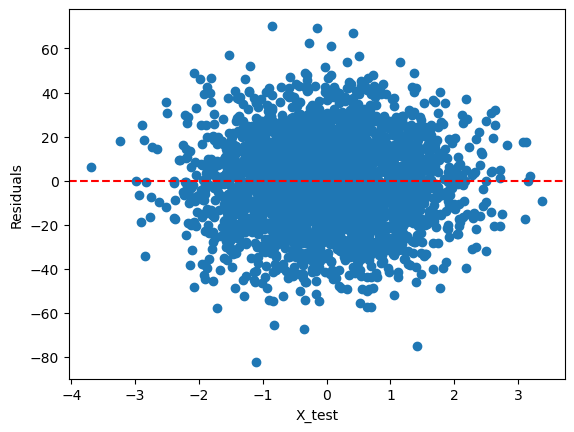

In [48]:
residuals = y_test - y_pred

plt.scatter(X_test, residuals)
plt.axhline(y=0, color='r', linestyle = '--')
plt.xlabel('X_test')
plt.ylabel('Residuals')
plt.show()

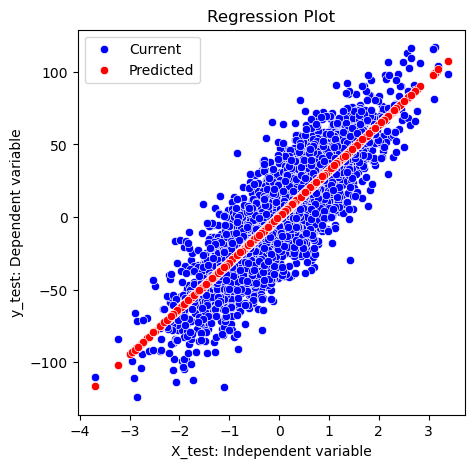

In [49]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=X_test.flatten(), y=y_test, label='Current', color = 'blue')
sns.scatterplot(x=X_test.flatten(), y=y_pred, label='Predicted', color='red')
plt.xlabel('X_test: Independent variable')
plt.ylabel('y_test: Dependent variable')
plt.title('Regression Plot')
plt.legend()
plt.show()

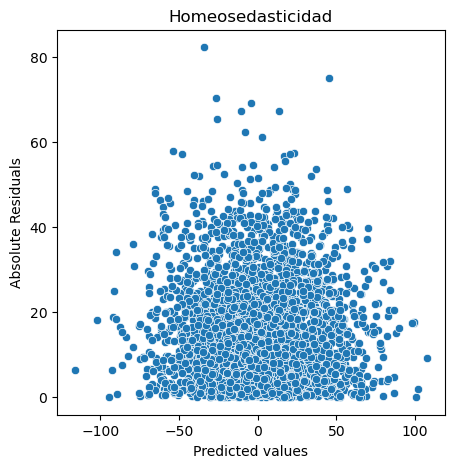

In [50]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_pred, y=np.abs(residuals))
plt.xlabel('Predicted values')
plt.ylabel('Absolute Residuals')
plt.title('Homeosedasticidad')
plt.show()

In [51]:
np.random.seed(42)
X_example = np.random.rand(200, 1)*100
y_example = 2*X_example.squeeze() + np.random.normal(0, X_example.squeeze(), 200)

X_train, X_test, y_train, y_test = train_test_split(X_example, y_example, test_size=.3, random_state=42)

model_h = LinearRegression()
model_h.fit(X_train, y_train)
y_pred_h = model_h.predict(X_test)

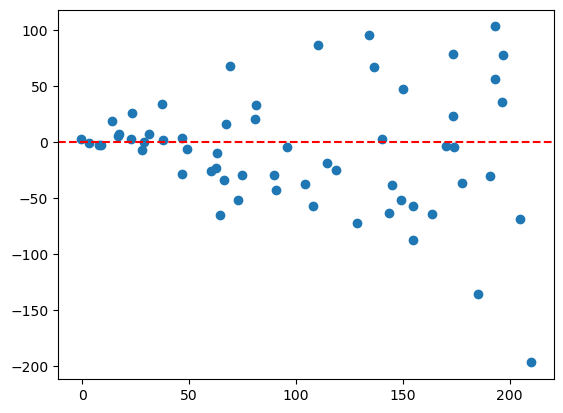

In [52]:
residuals_h = y_test - y_pred_h
plt.scatter(y_pred_h, residuals_h)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

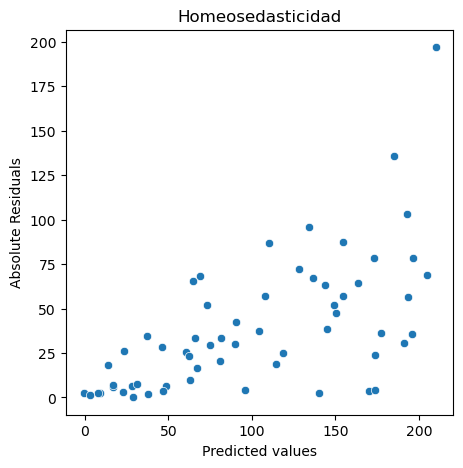

In [53]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_pred_h, y=np.abs(residuals_h))
plt.xlabel('Predicted values')
plt.ylabel('Absolute Residuals')
plt.title('Homeosedasticidad')
plt.show()

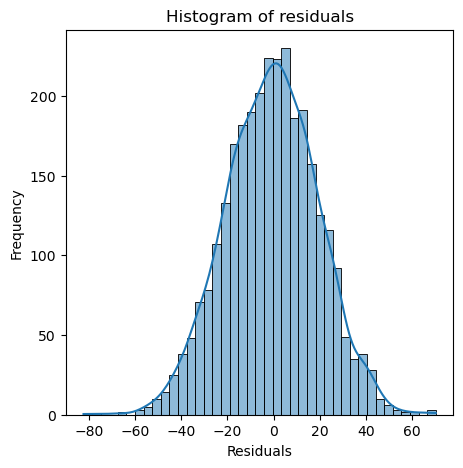

In [54]:
plt.figure(figsize=(5,5))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of residuals')
plt.show()

<Figure size 500x500 with 0 Axes>

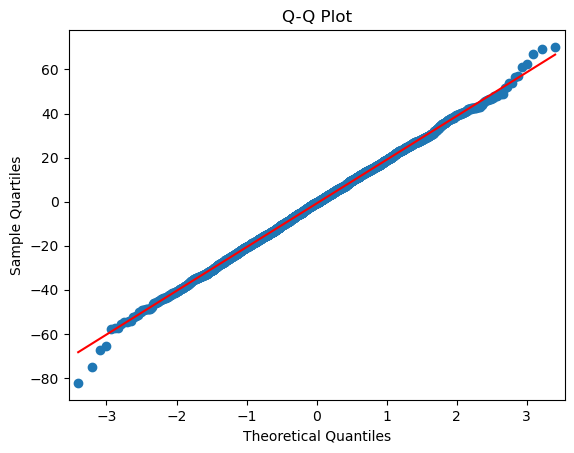

In [55]:
plt.figure(figsize=(5,5))
sm.qqplot(residuals, line='s')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quartiles')
plt.title('Q-Q Plot')
plt.show()

In [56]:
df = pd.read_csv('WineQT.csv')


In [57]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [58]:
X_w = df[df.columns.drop('quality')]
y_w =df['quality']

In [59]:
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=.3, random_state=42)

model_w=LinearRegression()
model_w.fit(X_train_w, y_train_w)
y_pred_w =model_w.predict(X_test_w)

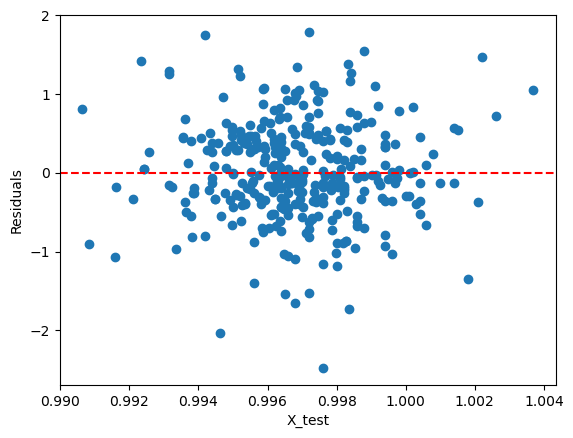

In [64]:
residuals_w = y_test_w - y_pred_w

plt.scatter(X_test_w['density'], residuals_w)
plt.axhline(y=0, color='r', linestyle = '--')
plt.xlabel('X_test')
plt.ylabel('Residuals')
plt.show()

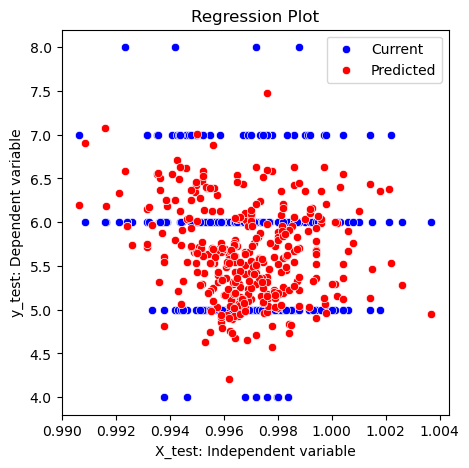

In [66]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=np.array(X_test_w['density']).flatten(), y=y_test_w, label='Current', color = 'blue')
sns.scatterplot(x=np.array(X_test_w['density']).flatten(), y=y_pred_w, label='Predicted', color='red')
plt.xlabel('X_test: Independent variable')
plt.ylabel('y_test: Dependent variable')
plt.title('Regression Plot')
plt.legend()
plt.show()

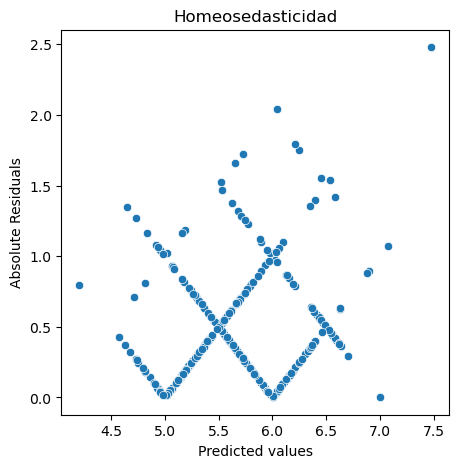

In [62]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_pred_w, y=np.abs(residuals_w))
plt.xlabel('Predicted values')
plt.ylabel('Absolute Residuals')
plt.title('Homeosedasticidad')
plt.show()